Dataset shape: (2356, 4)
   page_id                                               text  label  \
0     1012            FLASH SALE | LIMITED TIME ONLY Shop Now      1   
1      158                                Pillowcases & Shams      0   
2      108                                     Write a review      0   
3     1425  To start your return, simply click on the foll...      0   
4     1658                newsletter signup (privacy policy)       0   

   Pattern Category  
0           Urgency  
1  Not Dark Pattern  
2  Not Dark Pattern  
3  Not Dark Pattern  
4  Not Dark Pattern  
Dataset after adding hard negatives: (2643, 4)
label
0    1465
1    1178
Name: count, dtype: int64

After removing duplicates: (2407, 5)

Training samples: 1925
Test samples: 482
Features: 10000

================ LOGISTIC REGRESSION ================
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       281
           1       0.92      0.92      0.92       2

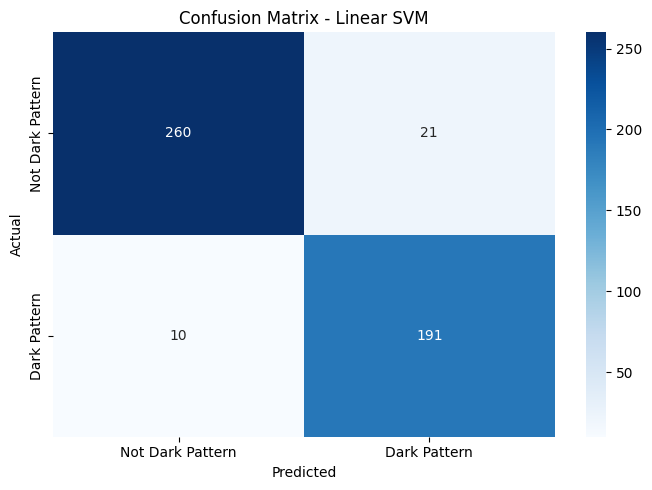


================ CROSS VALIDATION ================
AUC per fold: [np.float64(0.9839), np.float64(0.9838), np.float64(0.9894), np.float64(0.9752), np.float64(0.9742)]
Mean AUC: 0.9813
Std: 0.0058

Main model saved.
TF-IDF vectorizer saved.

================ CATEGORY MODEL ================
               precision    recall  f1-score   support

Forced Action       1.00      1.00      1.00         1
 Misdirection       1.00      0.69      0.81        32
  Obstruction       0.62      1.00      0.77         5
     Scarcity       0.97      0.97      0.97        59
     Sneaking       0.50      1.00      0.67         2
 Social Proof       0.94      1.00      0.97        62
      Urgency       0.93      0.95      0.94        40

     accuracy                           0.93       201
    macro avg       0.85      0.94      0.87       201
 weighted avg       0.94      0.93      0.93       201

Category model saved.
Category vectorizer saved.

MODEL TRAINING COMPLETE.


In [3]:
import pandas as pd
import joblib
import re
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv('../data/dark_patterns.csv')

print("Dataset shape:", df.shape)
print(df.head())
# ---------------------------------------------------------
# HARD NEGATIVE EXAMPLES
# These are normal e-commerce texts that contain words
# commonly associated with dark patterns.
# ---------------------------------------------------------

hard_negatives = [

    # ============================================================
    # NORMAL STOCK / AVAILABILITY
    # ============================================================

    "In stock",
    "In Stock",
    "Currently in stock",
    "Currently In Stock",
    "Available in stock",
    "This item is currently in stock",
    "Item is available in stock",
    "Item is currently available",
    "Available now",
    "Available for purchase",
    "Product is available",
    "Product available",
    "In stock and ready to ship",
    "Available and ready to ship",
    "Usually ships within 2 days",
    "Usually ships within 3 days",
    "Usually dispatched within 2 days",
    "Usually dispatched within 3 days",

    # ============================================================
    # CHECKOUT / PURCHASE UI
    # ============================================================

    "Available at checkout",
    "Available at checkout Available at checkout",
    "Available at checkout Available at checkout This item is a gift",
    "This item is a gift",
    "This item is a gift. Change",
    "Gift options available",
    "Gift wrap available",
    "Add to cart",
    "Add to Cart",
    "Buy now",
    "Buy Now",
    "Add to wishlist",
    "Add to Wish List",
    "Add to List",
    "Proceed to checkout",
    "Proceed to Checkout",
    "Go to cart",
    "View cart",
    "Shopping cart",

    # ============================================================
    # LOCATION / DELIVERY INFORMATION
    # ============================================================

    "Delivering to Mumbai",
    ".in Delivering to Mumbai Update location",
    "Delivering to Mumbai 400017",
    "Delivering to your location",
    "Delivering to your address",
    "Delivery available",
    "Delivery information",
    "Delivery details",
    "Shipping information",
    "Shipping details",
    "Update location",
    "Update your location",
    "Select your delivery location",
    "Enter your delivery location",
    "Enter your location",
    "Choose your location",
    "Change location",
    "Select location",
    "Deliver to this address",
    "Free delivery",
    "FREE delivery",
    "Free shipping",
    "FREE Shipping",

    # ============================================================
    # PRODUCT INFORMATION
    # ============================================================

    "Product information",
    "Product Information",
    "Product details",
    "Product Details",
    "Product description",
    "Product Description",
    "About this item",
    "About This Item",
    "Item details",
    "Item Details",
    "Item information",
    "Item Information",
    "Technical details",
    "Technical Details",
    "Specifications",
    "Product specifications",
    "Product features",
    "Features and details",
    "Item model number",
    "Model number",
    "Manufacturer information",
    "Manufacturer",
    "Brand",
    "Country of origin",
    "Date first available",
    "Date First Available",

    # ============================================================
    # PRODUCT DIMENSIONS / SPECIFICATIONS
    # ============================================================

    "Item Dimensions LxWxH",
    "Item Dimensions",
    "Product dimensions",
    "Product Dimensions",
    "Dimensions",
    "15 x 10 x 2 Centimeters",
    "10 x 15 x 2 Centimeters",
    "Size information",
    "Size chart",
    "Color information",
    "Material information",
    "Weight information",

    # ============================================================
    # NORMAL PRODUCT DESCRIPTION
    # ============================================================

    "Work in Style, Move in Comfort!",
    "Comfortable and stylish design",
    "Designed for everyday comfort",
    "Soft and comfortable fabric",
    "Stylish design",
    "Premium quality material",
    "High quality material",
    "Comfortable fit",
    "Perfect for everyday use",
    "Designed for everyday use",
    "Made with quality materials",
    "Durable and comfortable",
    "Lightweight and comfortable",
    "Classic design",
    "Modern design",
    "Simple and elegant design",
    "This product is designed for comfort",
    "This product is suitable for everyday use",
    "this product",
    "this item",
    "this trouser",
    "this shirt",
    "this dress",
    "this bag",
    "this case",

    # ============================================================
    # CUSTOMER REVIEWS / RATINGS
    # ============================================================

    "Customer reviews",
    "Customer Reviews",
    "Customer ratings",
    "Customer Ratings",
    "Reviews",
    "Ratings",
    "4.0 out of 5 stars",
    "4.5 out of 5 stars",
    "5.0 out of 5 stars",
    "3.5 out of 5 stars",
    "3.0 out of 5 stars",
    "2.0 out of 5 stars",
    "2,380 ratings",
    "1,250 ratings",
    "100 ratings",
    "500 ratings",
    "100+ ratings",
    "2380 ratings",
    "Customer reviews and ratings",
    "4.0 out of 5 stars 2,380 ratings",
    "4.5 out of 5 stars 1,250 ratings",

    # ============================================================
    # REVIEW METADATA
    # ============================================================

    "Reviewed in India",
    "Reviewed in Saudi Arabia",
    "Reviewed in the United Arab Emirates",
    "Reviewed in the United States",
    "Reviewed in the United Kingdom",
    "Reviewed in India on 20 June 2026",
    "Reviewed in Saudi Arabia on 20 June 2026",
    "Reviewed in the United Arab Emirates on 1 May 2026",
    "Reviewed in the United States on 20 June 2026",
    "Reviewed in India on 1 May 2026",
    "4 people found this helpful",
    "5 people found this helpful",
    "10 people found this helpful",
    "Was this review helpful?",
    "Helpful",
    "Customer questions and answers",

    # ============================================================
    # NORMAL RECOMMENDATION / RELATED PRODUCTS
    # ============================================================

    "Customers who bought this item also bought",
    "Customers who bought this item also bought Page 1 of 15 Start over",
    "Customers who viewed this item also viewed",
    "Customers who viewed items in your browsing history also viewed",
    "Customers who viewed items in your browsing history also viewed Page 1 of 5 Start over",
    "What other items do customers buy after viewing this item?",
    "Frequently bought together",
    "Similar products",
    "Related products",
    "Recently viewed items",
    "Your recently viewed items",
    "Your recently viewed",
    "Browse related products",
    "More buying choices",
    "Other sellers on Amazon",
    "Recommended products",
    "Related items",
    "You may also like",
    "Products related to this item",
    "Explore similar products",

    # ============================================================
    # NORMAL NAVIGATION / PAGE UI
    # ============================================================

    "Page 1 of 15",
    "Page 1 of 5",
    "Page 1 of 10",
    "Page 2 of 15",
    "Start over",
    "See all",
    "See more",
    "Read more",
    "Read less",
    "View all",
    "Learn more",
    "Previous page",
    "Next page",
    "Previous",
    "Next",
    "Back",
    "Continue",
    "Close",
    "More",

    # ============================================================
    # PRICE / DISCOUNT INFORMATION
    # ============================================================

    "Price details",
    "Price Details",
    "₹899.00",
    "₹1,999.00",
    "₹839.00",
    "55 percent savings",
    "58 percent savings",
    "Save 10 percent",
    "Save 20 percent",
    "Save 30 percent",
    "10 percent savings",
    "20 percent savings",
    "Discount details",
    "Price information",
    "List price",
    "MRP",
    "Maximum Retail Price",

    # ============================================================
    # RETURN / REFUND INFORMATION
    # ============================================================

    "Returns and refunds",
    "Returns and Refunds",
    "Return policy",
    "Refund policy",
    "10 days returnable",
    "7 days returnable",
    "30 days returnable",
    "Eligible for return",
    "Return information",
    "Easy returns",

    # ============================================================
    # PAYMENT / SECURITY
    # ============================================================

    "Secure transaction",
    "Secure Transaction",
    "Payment information",
    "Payment Information",
    "Payment options",
    "Multiple payment options",
    "Credit card",
    "Debit card",
    "Cash on delivery",
    "Privacy notice",
    "Privacy Notice",
    "Terms and conditions",
    "Terms and Conditions",
    "Terms of use",
    "Conditions of use",

    # ============================================================
    # NORMAL OFFERS / SERVICES
    # ============================================================

    "Bank offer",
    "Bank Offer",
    "1 offer",
    "Multiple offers",
    "Partner offers",
    "Partner Offers",
    "Get GST invoice",
    "Get GST invoice for your business",
    "Purchase protection",
    "Amazon Pay",
    "EMI available",
    "No cost EMI",

    # ============================================================
    # NORMAL PRODUCT / SELLER INFORMATION
    # ============================================================

    "Ships from Amazon",
    "Sold by Amazon",
    "Ships from seller",
    "Sold by seller",
    "Seller information",
    "Seller details",
    "Seller profile",
    "Visit the store",
    "Visit Store",
    "Brand store",
    "Store information",

    # ============================================================
    # NUMERIC / DATE UI NOISE
    # ============================================================

    "01 02 03 04 05 06 07 08 09 10 11 12",

    "01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31",

    "01 02 03 04 05 06 07 08 09 10 11 12 / 01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 /",

    # ============================================================
    # OTHER NORMAL E-COMMERCE UI
    # ============================================================

    "Select the department",
    "Select a department",
    "Search",
    "Search results",
    "Filter",
    "Sort by",
    "Customer service",
    "Help",
    "Contact us",
    "Sign in",
    "Create account",
    "Your account",
    "Your orders",
    "Returns and orders",
    "Order history",
    "Wishlist",
    "Cart",
    "Menu",
    "Categories",
    "Departments"
]

hard_negative_df = pd.DataFrame({
    "page_id": range(100000, 100000 + len(hard_negatives)),
    "text": hard_negatives,
    "label": [0] * len(hard_negatives),
    "Pattern Category": ["Not Dark Pattern"] * len(hard_negatives)
})

df = pd.concat([df, hard_negative_df], ignore_index=True)

print("Dataset after adding hard negatives:", df.shape)
print(df["label"].value_counts())

# ============================================================
# 2. TEXT CLEANING
# ============================================================

def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Keep useful punctuation information
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['clean_text'] = df['text'].apply(clean_text)


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates(subset=['clean_text', 'label']).reset_index(drop=True)

print("\nAfter removing duplicates:", df.shape)


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 5. TF-IDF
# ============================================================


tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=1,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTraining samples:", X_train_tfidf.shape[0])
print("Test samples:", X_test_tfidf.shape[0])
print("Features:", X_train_tfidf.shape[1])


# ============================================================
# 6. LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    max_iter=2000,
    C=0.5,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
y_prob_lr = lr.predict_proba(X_test_tfidf)[:, 1]

print("\n================ LOGISTIC REGRESSION ================")

print(classification_report(y_test, y_pred_lr))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob_lr), 4)
)


# ============================================================
# 7. LINEAR SVM
# ============================================================

svm = LinearSVC(
    C=0.5,
    class_weight='balanced',
    random_state=42,
    max_iter=3000
)

svm_calibrated = CalibratedClassifierCV(
    svm,
    cv=5
)

svm_calibrated.fit(X_train_tfidf, y_train)

y_pred_svm = svm_calibrated.predict(X_test_tfidf)
y_prob_svm = svm_calibrated.predict_proba(X_test_tfidf)[:, 1]

print("\n================ LINEAR SVM ================")

print(classification_report(y_test, y_pred_svm))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob_svm), 4)
)


# ============================================================
# 8. CHOOSE BEST MODEL
# ============================================================

lr_auc = roc_auc_score(y_test, y_prob_lr)
svm_auc = roc_auc_score(y_test, y_prob_svm)

if svm_auc >= lr_auc:

    best_model = svm_calibrated
    best_name = "Linear SVM"

    y_pred_best = y_pred_svm
    y_prob_best = y_prob_svm

else:

    best_model = lr
    best_name = "Logistic Regression"

    y_pred_best = y_pred_lr
    y_prob_best = y_prob_lr


print("\n========================================")
print("BEST MODEL:", best_name)
print("BEST AUC:", round(max(lr_auc, svm_auc), 4))
print("========================================")


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Dark Pattern', 'Dark Pattern'],
    yticklabels=['Not Dark Pattern', 'Dark Pattern']
)

plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()

plt.savefig(
    '../data/confusion_matrix.png',
    dpi=150
)

plt.show()


# ============================================================
# 10. CROSS VALIDATION
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_model,
    X_train_tfidf,
    y_train,
    cv=skf,
    scoring='roc_auc'
)

print("\n================ CROSS VALIDATION ================")

print(
    "AUC per fold:",
    [round(x, 4) for x in cv_scores]
)

print(
    "Mean AUC:",
    round(cv_scores.mean(), 4)
)

print(
    "Std:",
    round(cv_scores.std(), 4)
)


# ============================================================
# 11. SAVE MAIN MODEL
# ============================================================

joblib.dump(
    best_model,
    '../models/best_model.pkl'
)

joblib.dump(
    tfidf,
    '../models/tfidf_vectorizer.pkl'
)

print("\nMain model saved.")
print("TF-IDF vectorizer saved.")


# ============================================================
# 12. CATEGORY MODEL
# ============================================================

print("\n================ CATEGORY MODEL ================")

dark_df = df[df['label'] == 1].copy()

X_cat = dark_df['clean_text']
y_cat = dark_df['Pattern Category']


X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_cat,
    y_cat,
    test_size=0.20,
    random_state=42,
    stratify=y_cat
)


# IMPORTANT:
# Fit a separate vectorizer for category classification.
category_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_cat_train_tfidf = category_tfidf.fit_transform(X_cat_train)
X_cat_test_tfidf = category_tfidf.transform(X_cat_test)


category_model = LogisticRegression(
    max_iter=2000,
    C=0.5,
    class_weight='balanced',
    random_state=42
)

category_model.fit(
    X_cat_train_tfidf,
    y_cat_train
)

category_predictions = category_model.predict(
    X_cat_test_tfidf
)

print(
    classification_report(
        y_cat_test,
        category_predictions
    )
)


# ============================================================
# 13. SAVE CATEGORY MODEL + VECTORIZER
# ============================================================

joblib.dump(
    category_model,
    '../models/category_model.pkl'
)

joblib.dump(
    category_tfidf,
    '../models/category_tfidf_vectorizer.pkl'
)

print("Category model saved.")
print("Category vectorizer saved.")


# ============================================================
# 14. SHOW IMPORTANT FEATURES
# ============================================================

if best_name == "Logistic Regression":

    feature_names = tfidf.get_feature_names_out()
    coefficients = lr.coef_[0]

    top_positive_idx = coefficients.argsort()[-20:][::-1]
    top_negative_idx = coefficients.argsort()[:20]

    print("\nTop features indicating DARK PATTERN:")

    for i in top_positive_idx:
        print(
            feature_names[i],
            round(coefficients[i], 3)
        )

    print("\nTop features indicating NORMAL TEXT:")

    for i in top_negative_idx:
        print(
            feature_names[i],
            round(coefficients[i], 3)
        )


print("\nMODEL TRAINING COMPLETE.")